In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics ,linear_model as lir, svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn

In [ ]:
data = pd.read_csv("diabetes_data_upload.csv")
data.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [ ]:
data.isnull().values.any()

False

In [ ]:
print("Age",data['Age'].dtypes)

for i in data.columns[1:]:
  print("\n",i,data[i].value_counts())

Age int64

 Gender Male      328
Female    192
Name: Gender, dtype: int64

 Polyuria No     262
Yes    258
Name: Polyuria, dtype: int64

 Polydipsia No     287
Yes    233
Name: Polydipsia, dtype: int64

 sudden weight loss No     303
Yes    217
Name: sudden weight loss, dtype: int64

 weakness Yes    305
No     215
Name: weakness, dtype: int64

 Polyphagia No     283
Yes    237
Name: Polyphagia, dtype: int64

 Genital thrush No     404
Yes    116
Name: Genital thrush, dtype: int64

 visual blurring No     287
Yes    233
Name: visual blurring, dtype: int64

 Itching No     267
Yes    253
Name: Itching, dtype: int64

 Irritability No     394
Yes    126
Name: Irritability, dtype: int64

 delayed healing No     281
Yes    239
Name: delayed healing, dtype: int64

 partial paresis No     296
Yes    224
Name: partial paresis, dtype: int64

 muscle stiffness No     325
Yes    195
Name: muscle stiffness, dtype: int64

 Alopecia No     341
Yes    179
Name: Alopecia, dtype: int64

 Obesity No    

In [ ]:
print(min(data['Age']),max(data['Age']))

16 90


In [ ]:
data['Gender'] = data['Gender'].replace(['Male','Female'],[1,0])
data['Gender']

0      1
1      1
2      1
3      1
4      1
      ..
515    0
516    0
517    0
518    0
519    1
Name: Gender, Length: 520, dtype: int64

In [ ]:
data['Polyuria'] = data['Polyuria'].replace(['Yes','No'],[1,0])
data['Polyuria']

0      0
1      0
2      1
3      0
4      1
      ..
515    1
516    1
517    1
518    0
519    0
Name: Polyuria, Length: 520, dtype: int64

In [ ]:
data['Polydipsia'] = data['Polydipsia'].replace(['Yes','No'],[1,0])
data['Polydipsia']

0      1
1      0
2      0
3      0
4      1
      ..
515    1
516    1
517    1
518    0
519    0
Name: Polydipsia, Length: 520, dtype: int64

In [ ]:
data['sudden weight loss'] = data['sudden weight loss'].replace(['Yes','No'],[1,0])
data['sudden weight loss']

0      0
1      0
2      0
3      1
4      1
      ..
515    1
516    1
517    1
518    0
519    0
Name: sudden weight loss, Length: 520, dtype: int64

In [ ]:
data['weakness'] = data['weakness'].replace(['Yes','No'],[1,0])
data['weakness']

0      1
1      1
2      1
3      1
4      1
      ..
515    0
516    1
517    1
518    1
519    0
Name: weakness, Length: 520, dtype: int64

In [ ]:
data['Polyphagia'] = data['Polyphagia'].replace(['Yes','No'],[1,0])
data['Polyphagia']

0      0
1      0
2      1
3      1
4      1
      ..
515    1
516    1
517    1
518    0
519    0
Name: Polyphagia, Length: 520, dtype: int64

In [ ]:
data['Genital thrush'] = data['Genital thrush'].replace(['Yes','No'],[1,0])
data['Genital thrush']

0      0
1      0
2      0
3      1
4      0
      ..
515    0
516    0
517    0
518    0
519    0
Name: Genital thrush, Length: 520, dtype: int64

In [ ]:
data['visual blurring'] = data['visual blurring'].replace(['Yes','No'],[1,0])
data['visual blurring']

0      0
1      1
2      0
3      0
4      1
      ..
515    0
516    0
517    1
518    1
519    0
Name: visual blurring, Length: 520, dtype: int64

In [ ]:
data['Itching'] = data['Itching'].replace(['Yes','No'],[1,0])
data['Itching']

0      1
1      0
2      1
3      1
4      1
      ..
515    1
516    1
517    0
518    1
519    0
Name: Itching, Length: 520, dtype: int64

In [ ]:
data['Irritability'] = data['Irritability'].replace(['Yes','No'],[1,0])
data['Irritability']

0      0
1      0
2      0
3      0
4      1
      ..
515    0
516    1
517    0
518    0
519    0
Name: Irritability, Length: 520, dtype: int64

In [ ]:
data['delayed healing'] = data['delayed healing'].replace(['Yes','No'],[1,0])
data['delayed healing']

0      1
1      0
2      1
3      1
4      1
      ..
515    1
516    1
517    0
518    1
519    0
Name: delayed healing, Length: 520, dtype: int64

In [ ]:
data['partial paresis'] = data['partial paresis'].replace(['Yes','No'],[1,0])
data['partial paresis']

0      0
1      1
2      0
3      0
4      1
      ..
515    1
516    1
517    1
518    0
519    0
Name: partial paresis, Length: 520, dtype: int64

In [ ]:
data['muscle stiffness'] = data['muscle stiffness'].replace(['Yes','No'],[1,0])
data['muscle stiffness']

0      1
1      0
2      1
3      0
4      1
      ..
515    0
516    0
517    1
518    0
519    0
Name: muscle stiffness, Length: 520, dtype: int64

In [ ]:
data['Alopecia'] = data['Alopecia'].replace(['Yes','No'],[1,0])
data['Alopecia']

0      1
1      1
2      1
3      0
4      1
      ..
515    0
516    0
517    0
518    1
519    0
Name: Alopecia, Length: 520, dtype: int64

In [ ]:
data['Obesity'] = data['Obesity'].replace(['Yes','No'],[1,0])
data['Obesity']

0      1
1      0
2      0
3      0
4      1
      ..
515    0
516    0
517    1
518    0
519    0
Name: Obesity, Length: 520, dtype: int64

In [ ]:
data['class'] = data['class'].replace(['Positive','Negative'],[1,0])
data['class']

0      1
1      1
2      1
3      1
4      1
      ..
515    1
516    1
517    1
518    0
519    0
Name: class, Length: 520, dtype: int64

In [ ]:
data.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(data.iloc[:,:10],data['class'], test_size=0.3,random_state = 20)

list_of_modals_and_accuracy = {}

Heat map


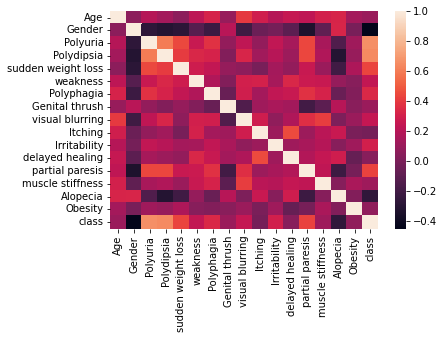

In [ ]:

seaborn.heatmap(data.corr())
print("Heat map")


confusion_matrix : 

 [[53  6]
 [ 4 93]]

Accuracy is :  0.9358974358974359

Classification Report
               precision    recall  f1-score   support

           0       0.93      0.90      0.91        59
           1       0.94      0.96      0.95        97

    accuracy                           0.94       156
   macro avg       0.93      0.93      0.93       156
weighted avg       0.94      0.94      0.94       156



/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


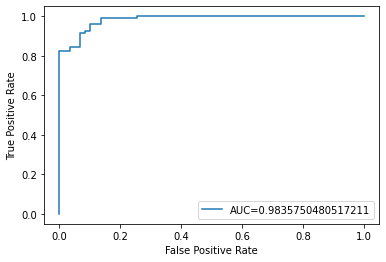

In [ ]:
model = lir.LogisticRegression()
model.fit(X_train,y_train)
y_pred  = model.predict(X_test)

results = metrics.confusion_matrix(y_test, y_pred)
print("\nconfusion_matrix : \n\n",results)
print("\nAccuracy is : ",metrics.accuracy_score(y_test, y_pred))
print("\nClassification Report\n",metrics.classification_report(y_test, y_pred))


list_of_modals_and_accuracy["Logistic Regression"] = metrics.accuracy_score(y_test, y_pred)
y_pred_proba = model.predict_proba(X_test)[::,1]
fpr1, tpr1, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)

plt.plot(fpr1,tpr1,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()


confusion_matrix : 

 [[50  9]
 [ 6 91]]

Accuracy is :  0.9038461538461539

Classification Report
               precision    recall  f1-score   support

           0       0.89      0.85      0.87        59
           1       0.91      0.94      0.92        97

    accuracy                           0.90       156
   macro avg       0.90      0.89      0.90       156
weighted avg       0.90      0.90      0.90       156



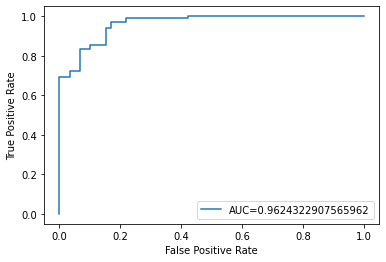

In [ ]:
nv = GaussianNB()
nv.fit(X_train,y_train)
y_pred = nv.predict(X_test)

results = metrics.confusion_matrix(y_test, y_pred)
print("\nconfusion_matrix : \n\n",results)
print("\nAccuracy is : ",metrics.accuracy_score(y_test, y_pred))
print("\nClassification Report\n",metrics.classification_report(y_test, y_pred))


list_of_modals_and_accuracy["Naïve bayes"] = metrics.accuracy_score(y_test, y_pred)

y_pred_proba = nv.predict_proba(X_test)[::,1]
fpr2, tpr2, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)

plt.plot(fpr2,tpr2,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()


confusion_matrix : 

 [[51  8]
 [ 6 91]]

Accuracy is :  0.9102564102564102

Classification Report
               precision    recall  f1-score   support

           0       0.89      0.86      0.88        59
           1       0.92      0.94      0.93        97

    accuracy                           0.91       156
   macro avg       0.91      0.90      0.90       156
weighted avg       0.91      0.91      0.91       156



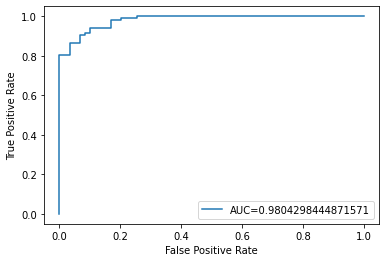

In [ ]:
modal = svm.SVC(kernel = "linear",probability=True)
modal.fit(X_train, y_train)
y_pred = modal.predict(X_test)

results = metrics.confusion_matrix(y_test, y_pred)
print("\nconfusion_matrix : \n\n",results)
print("\nAccuracy is : ",metrics.accuracy_score(y_test, y_pred))
print("\nClassification Report\n",metrics.classification_report(y_test, y_pred))

list_of_modals_and_accuracy["Support Vector machine"] = metrics.accuracy_score(y_test, y_pred)

y_pred_proba = modal.predict_proba(X_test)[:,1]
fpr3, tpr3, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)

plt.plot(fpr3,tpr3,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()


confusion_matrix : 

 [[54  5]
 [ 8 89]]

Accuracy is :  0.9166666666666666

Classification Report
               precision    recall  f1-score   support

           0       0.87      0.92      0.89        59
           1       0.95      0.92      0.93        97

    accuracy                           0.92       156
   macro avg       0.91      0.92      0.91       156
weighted avg       0.92      0.92      0.92       156



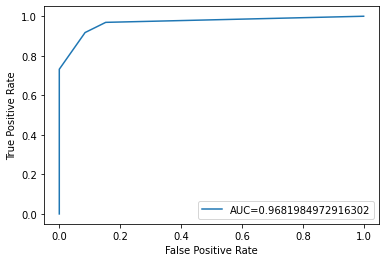

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

results = metrics.confusion_matrix(y_test, y_pred)
print("\nconfusion_matrix : \n\n",results)
print("\nAccuracy is : ",metrics.accuracy_score(y_test, y_pred))
print("\nClassification Report\n",metrics.classification_report(y_test, y_pred))

list_of_modals_and_accuracy["KNN"] = metrics.accuracy_score(y_test, y_pred)


y_pred_proba = knn.predict_proba(X_test)[:,1]
fpr3, tpr3, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)



plt.plot(fpr3,tpr3,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()


confusion_matrix : 

 [[58  1]
 [ 0 97]]

Accuracy is :  0.9935897435897436

Classification Report
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        59
           1       0.99      1.00      0.99        97

    accuracy                           0.99       156
   macro avg       0.99      0.99      0.99       156
weighted avg       0.99      0.99      0.99       156



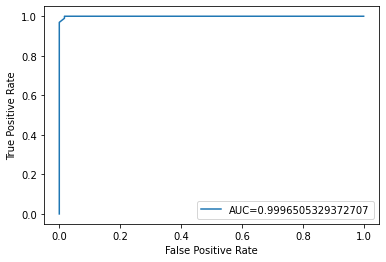

In [ ]:
model = RandomForestClassifier(n_estimators = 1000, random_state = 42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)

results = metrics.confusion_matrix(y_test, y_pred)
print("\nconfusion_matrix : \n\n",results)
print("\nAccuracy is : ",metrics.accuracy_score(y_test, y_pred))
print("\nClassification Report\n",metrics.classification_report(y_test, y_pred))

list_of_modals_and_accuracy["Random forest"] = metrics.accuracy_score(y_test, y_pred)


y_pred_proba = model.predict_proba(X_test)[:,1]
fpr4, tpr4, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)

plt.plot(fpr4,tpr4,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()

In [ ]:
print("The Modal with Highest Accuracy :",max(list_of_modals_and_accuracy,key = lambda a:list_of_modals_and_accuracy[a]),"With Accuracy of",list_of_modals_and_accuracy[max(list_of_modals_and_accuracy,key = lambda a:list_of_modals_and_accuracy[a])])

The Modal with Highest Accuracy : Random forest With Accuracy of 0.9935897435897436


array([<matplotlib.axes._subplots.AxesSubplot object at 0x7f50f41b0e20>,
      dtype=object)

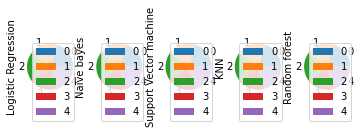

In [ ]:
df = pd.DataFrame(list_of_modals_and_accuracy,index=[i for i in range(len(list_of_modals_and_accuracy))])
df.plot.pie(subplots=True)

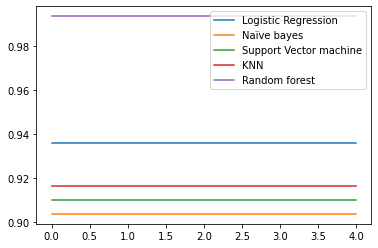

In [ ]:
df.plot()

In [ ]:
#seaborn.boxplot(data = data)

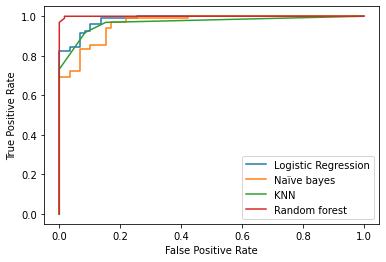

In [ ]:
plt.plot(fpr1,tpr1,label="Logistic Regression")
plt.plot(fpr2,tpr2,label="Naïve bayes")
plt.plot(fpr3,tpr3,label="KNN")
plt.plot(fpr4,tpr4,label="Random forest")

plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()